# Fish diversity eDNA metabarcoding - visualizações

## Configuração

In [285]:
# Configuração

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
os.chdir('/workspaces/Fish_diversity_eDNA_Metabarcoding/5_notebooks')
%matplotlib inline

In [286]:
# Carregar e inspecionar metadados
metadata = pd.read_csv('../2_metadata/sample_metadata.tsv', sep='\t', skiprows=[1])
metadata

,sample-id,geo_local,escala_local,data_coleta,latitude,longitude
0,DRR030421,Chura,Aquarium,2014-06-03,26.69,127.88
1,DRR030422,Chura,Aquarium,2014-06-03,26.69,127.88
2,DRR030423,Chura,Aquarium,2014-06-03,26.69,127.88
3,DRR030424,Chura,Aquarium,2014-06-03,26.69,127.88
4,DRR030425,Bise,Coral_reefs,2014-06-03,26.71,127.88
5,DRR030426,Bise,Coral_reefs,2014-06-03,26.71,127.88
6,DRR030427,Bise,Coral_reefs,2014-06-03,26.71,127.88
7,DRR030428,Bise,Coral_reefs,2014-06-03,26.71,127.88


## Diversidade alfa e rarefacão

In [287]:
# Carregar dados de rarefação
df_rarefc = pd.read_csv('../4_output/2_exported_tables/1_alpha/rarefc_observed_features.csv')
# Isolar colunas de id e de profundidade
cols_depth = [col for col in df_rarefc.columns if col.replace('.', '', 1).isdigit() or 'depth' in col or '_' in col]
# Filtrar
cols_num = [col for col in df_rarefc.columns if any(char.isdigit() for char in col) and 'depth' in col or col.replace('_', '').isdigit()]
# Reorganizar df
df_rarefc.rename(columns={df_rarefc.columns[0]: 'sample-id'}, inplace=True)
# Inspecionar
df_rarefc

,sample-id,depth-1_iter-1,depth-1_iter-2,depth-1_iter-3,depth-1_iter-4,depth-1_iter-5,depth-1_iter-6,depth-1_iter-7,depth-1_iter-8,depth-1_iter-9,...,depth-100000_iter-4,depth-100000_iter-5,depth-100000_iter-6,depth-100000_iter-7,depth-100000_iter-8,depth-100000_iter-9,depth-100000_iter-10,geo_local,escala_local,data_coleta
0,DRR030421,1,1,1,1,1,1,1,1,1,...,37.0,37.0,37.0,37.0,37.0,37.0,37.0,Chura,Aquarium,2014-06-03
1,DRR030422,1,1,1,1,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chura,Aquarium,2014-06-03
2,DRR030423,1,1,1,1,1,1,1,1,1,...,42.0,42.0,43.0,43.0,43.0,42.0,43.0,Chura,Aquarium,2014-06-03
3,DRR030424,1,1,1,1,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chura,Aquarium,2014-06-03
4,DRR030425,1,1,1,1,1,1,1,1,1,...,119.0,118.0,122.0,121.0,118.0,115.0,121.0,Bise,Coral_reefs,2014-06-03
5,DRR030426,1,1,1,1,1,1,1,1,1,...,109.0,115.0,114.0,110.0,110.0,111.0,114.0,Bise,Coral_reefs,2014-06-03
6,DRR030427,1,1,1,1,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bise,Coral_reefs,2014-06-03
7,DRR030428,1,1,1,1,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bise,Coral_reefs,2014-06-03


In [288]:
# Mesclar com metadados e inspecionar
df_rarefc = pd.merge(metadata[['sample-id', 'escala_local']], df_rarefc, on='sample-id')
df_rarefc

,sample-id,escala_local_x,depth-1_iter-1,depth-1_iter-2,depth-1_iter-3,depth-1_iter-4,depth-1_iter-5,depth-1_iter-6,depth-1_iter-7,depth-1_iter-8,...,depth-100000_iter-4,depth-100000_iter-5,depth-100000_iter-6,depth-100000_iter-7,depth-100000_iter-8,depth-100000_iter-9,depth-100000_iter-10,geo_local,escala_local_y,data_coleta
0,DRR030421,Aquarium,1,1,1,1,1,1,1,1,...,37.0,37.0,37.0,37.0,37.0,37.0,37.0,Chura,Aquarium,2014-06-03
1,DRR030422,Aquarium,1,1,1,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chura,Aquarium,2014-06-03
2,DRR030423,Aquarium,1,1,1,1,1,1,1,1,...,42.0,42.0,43.0,43.0,43.0,42.0,43.0,Chura,Aquarium,2014-06-03
3,DRR030424,Aquarium,1,1,1,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chura,Aquarium,2014-06-03
4,DRR030425,Coral_reefs,1,1,1,1,1,1,1,1,...,119.0,118.0,122.0,121.0,118.0,115.0,121.0,Bise,Coral_reefs,2014-06-03
5,DRR030426,Coral_reefs,1,1,1,1,1,1,1,1,...,109.0,115.0,114.0,110.0,110.0,111.0,114.0,Bise,Coral_reefs,2014-06-03
6,DRR030427,Coral_reefs,1,1,1,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bise,Coral_reefs,2014-06-03
7,DRR030428,Coral_reefs,1,1,1,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bise,Coral_reefs,2014-06-03


In [289]:
# Mudar nomes dos ambientes
df_rarefc['escala_local_x'] = df_rarefc['escala_local_x'].replace({
    'Aquarium': 'Aquário',
    'Coral_reefs': 'Recife de corais'
})

In [290]:
# Filtrar colunas de dados gerados pelo QIIME
dados_cols = [col for col in df_rarefc.columns if col.startswith('depth-')]

# Extrair e ordenar a lista das profundidades testadas na curva de rarefação
depths = sorted(list(set([
    int(col.split('depth-')[1].split('_iter')[0]) for col in dados_cols])))

# Criar novo df para armazenar os cálculos da curva
df_calculo = pd.DataFrame()

# Associar linha a ambiente
df_calculo['escala_local'] = df_rarefc['escala_local_x']

# Calcular a média das dez iterações de cada profundidade por amostra
for p in depths:
    cols_p = [col for col in dados_cols if col.startswith(f'depth-{p}_iter-')]
    df_calculo[p] = df_rarefc[cols_p].mean(axis=1)

# Agrupar os dados por ambiente e calcular média e desvio padrão
df_group = df_calculo.groupby('escala_local').agg(['mean', 'std'])

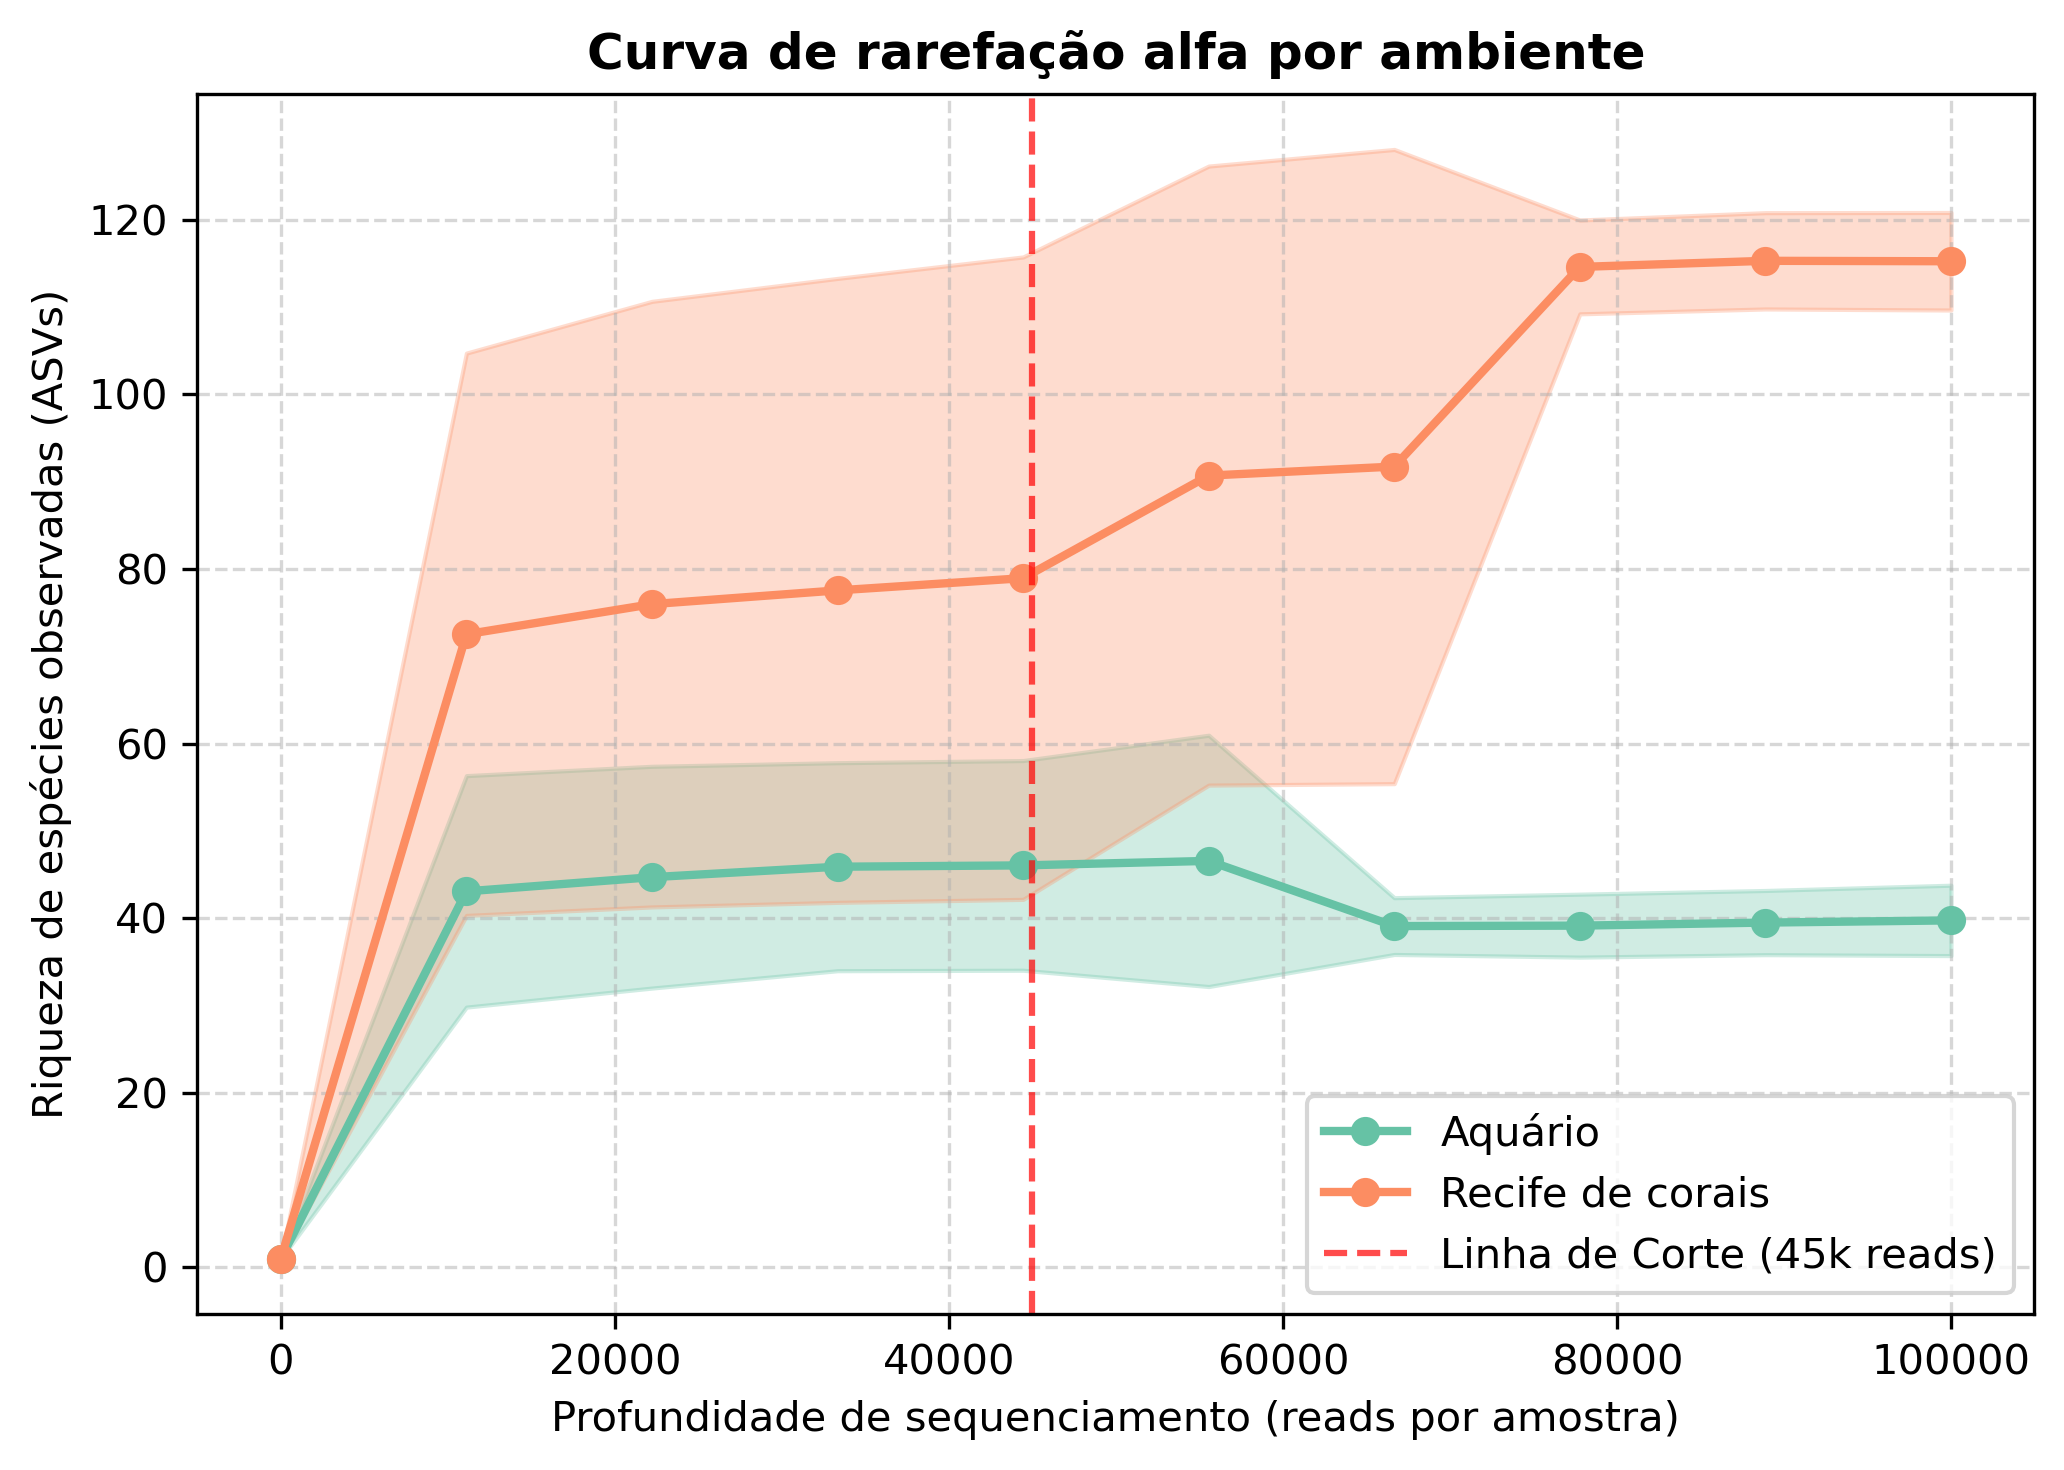

In [291]:
# Gerar figura
plt.figure(figsize=(7, 5), dpi=300)

# Definir cores
cmap = plt.get_cmap('Set2')
cores = {
    'Aquário': cmap(0),
    'Recife de corais': cmap(1)
}

for ambiente in df_group.index:
    medias = df_group.loc[ambiente, (slice(None), 'mean')].values
    desvios = df_group.loc[ambiente, (slice(None), 'std')].values
    
    # Linha principal da média
    plt.plot(depths, medias, marker='o', linewidth=2, label=ambiente, color=cores[ambiente])
    
    # Sombra representando o desvio padrão (variabilidade entre as 4 runs de cada ambiente)
    plt.fill_between(depths, medias - desvios, medias + desvios, alpha=0.3, color=cores[ambiente])

# Linha vertical tracejada marcando o limite de 45000 reads
plt.axvline(x=45000, color='red', linestyle='--', alpha=0.7, label='Linha de Corte (45k reads)')

# Estilizar e adicionar eixos
plt.title('Curva de rarefação alfa por ambiente', fontsize=12, fontweight='bold')
plt.xlabel('Profundidade de sequenciamento (reads por amostra)', fontsize=10)
plt.ylabel('Riqueza de espécies observadas (ASVs)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()

# Salvar e mostrar figura
plt.savefig('./figures/curva_rarefacao_asvs.png', dpi=300)
plt.show()

In [292]:
# Carregar dados de ASVs
alpha_df = pd.read_csv('../4_output/2_exported_tables/1_alpha/observed_features.tsv', sep='\t')
alpha_df = alpha_df.rename(columns={'Unnamed: 0': 'id'})
alpha_df

,id,observed_features
0,DRR030421,37
1,DRR030422,63
2,DRR030423,40
3,DRR030424,46
4,DRR030425,116
5,DRR030426,113
6,DRR030427,50
7,DRR030428,45


In [293]:
# Mesclar com df de metadados e inspecionar
alpha_df = pd.merge(metadata, alpha_df, left_on='sample-id', right_on='id')
alpha_df.drop(columns=['id'], inplace=True)
alpha_df

,sample-id,geo_local,escala_local,data_coleta,latitude,longitude,observed_features
0,DRR030421,Chura,Aquarium,2014-06-03,26.69,127.88,37
1,DRR030422,Chura,Aquarium,2014-06-03,26.69,127.88,63
2,DRR030423,Chura,Aquarium,2014-06-03,26.69,127.88,40
3,DRR030424,Chura,Aquarium,2014-06-03,26.69,127.88,46
4,DRR030425,Bise,Coral_reefs,2014-06-03,26.71,127.88,116
5,DRR030426,Bise,Coral_reefs,2014-06-03,26.71,127.88,113
6,DRR030427,Bise,Coral_reefs,2014-06-03,26.71,127.88,50
7,DRR030428,Bise,Coral_reefs,2014-06-03,26.71,127.88,45


In [294]:
alpha_df['escala_local'] = alpha_df['escala_local'].replace({
    'Aquarium': 'Aquário',
    'Coral_reefs': 'Recife de corais'
})

/home/vscode/miniforge3/envs/qiime2_amplicon/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/vscode/miniforge3/envs/qiime2_amplicon/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/vscode/miniforge3/envs/qiime2_amplicon/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


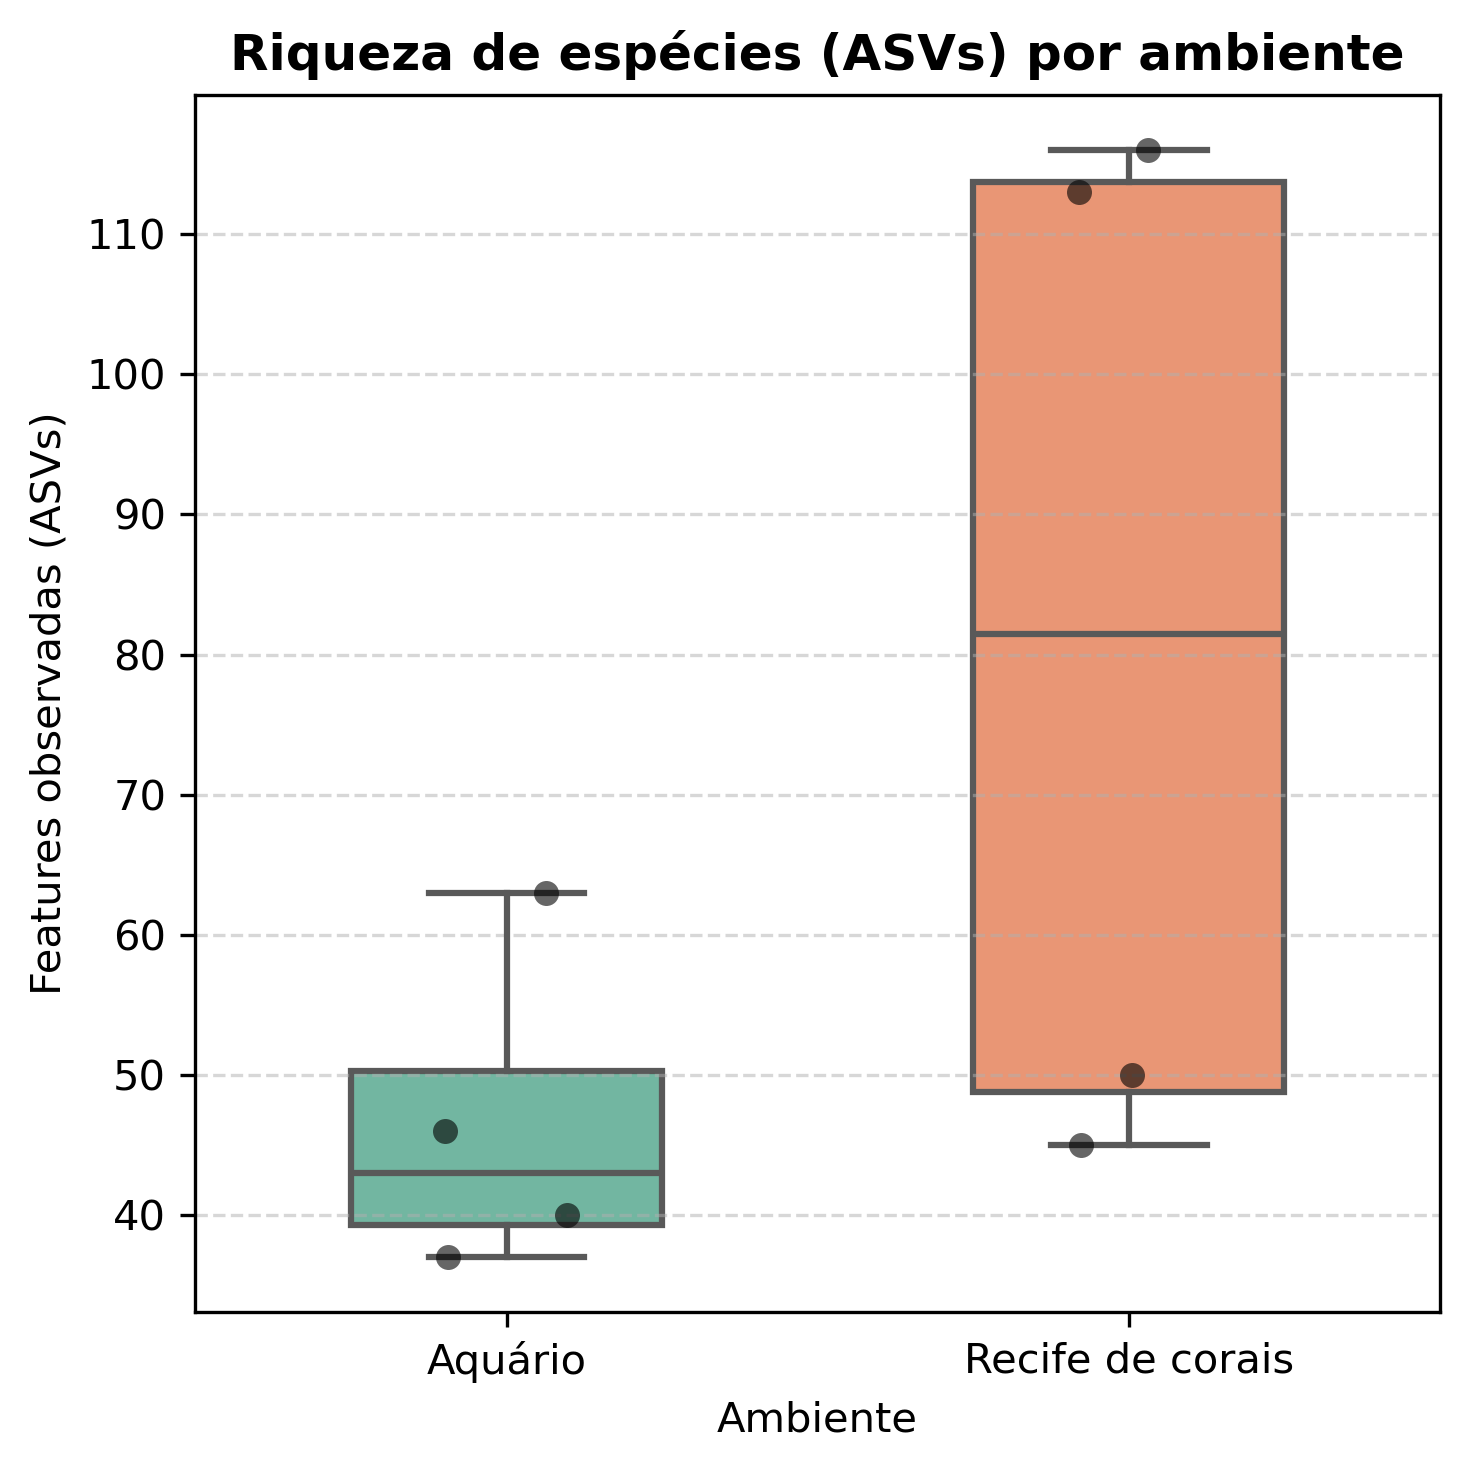

In [295]:
# Configurar e plotar o gráfico
plt.figure(figsize=(5, 5), dpi=300)

# Boxplot para mostrar a distribuição (mediana, quartetos)
sns.boxplot(data=alpha_df, x='escala_local', y='observed_features', palette='Set2', width=0.5)

# Stripplot por cima para mostrar os pontos exatos de cada amostra
sns.stripplot(data=alpha_df, x='escala_local', y='observed_features', color='black', alpha=0.6, size=6, jitter=0.1)

# Ajustes estéticos
plt.title('Riqueza de espécies (ASVs) por ambiente', fontsize=12, fontweight='bold')
plt.ylabel('Features observadas (ASVs)', fontsize=10)
plt.xlabel('Ambiente', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Salvar e mostrar figura
plt.tight_layout()
plt.savefig('./figures/boxplot_riqueza.png', dpi=300)
plt.show()

In [296]:
# Carregar dados de diversidade beta e inspecionar
pcoa_data = pd.read_csv('../4_output/2_exported_tables/2_beta/jaccard/jaccard_ordination.txt', delim_whitespace=True, skiprows=9, header=None)
pcoa_data = pcoa_data[pcoa_data[0].astype(str).str.startswith('DRR')].copy()
pcoa_data

/tmp/ipykernel_18268/1944887388.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pcoa_data = pd.read_csv('../4_output/2_exported_tables/2_beta/jaccard/jaccard_ordination.txt', delim_whitespace=True, skiprows=9, header=None)


,0,1,2,3,4,5,6,7,8
0,DRR030421,-0.37417309752052447,0.331650,-0.072089,0.030143,-0.240291,0.271031,-0.053569,-0.0
1,DRR030422,-0.3236614755001298,0.317568,-0.124411,0.069711,0.243943,-0.282536,0.066966,-0.0
2,DRR030423,-0.1879134019134022,-0.443683,-0.009382,0.015125,-0.259744,-0.162225,0.202037,-0.0
3,DRR030424,-0.23410214180699218,-0.429156,0.030826,-0.053509,0.266807,0.164255,-0.182853,-0.0
4,DRR030425,0.34063638202050195,0.000861,-0.314923,-0.039065,-0.135547,-0.158689,-0.285542,-0.0
5,DRR030426,0.37135020461919643,0.028906,-0.290272,-0.071579,0.128857,0.197503,0.260867,-0.0
6,DRR030427,0.26701393742120155,0.037308,0.343849,0.452735,0.012551,0.022033,-0.013507,-0.0
7,DRR030428,0.14084959268014788,0.156546,0.436402,-0.403562,-0.016575,-0.051372,0.005602,-0.0


In [297]:
# Limpar df
pcoa_df = pcoa_data.iloc[:, :3]
pcoa_df.columns = ['sample-id', 'PC1', 'PC2']
pcoa_df

,sample-id,PC1,PC2
0,DRR030421,-0.37417309752052447,0.331650
1,DRR030422,-0.3236614755001298,0.317568
2,DRR030423,-0.1879134019134022,-0.443683
3,DRR030424,-0.23410214180699218,-0.429156
4,DRR030425,0.34063638202050195,0.000861
5,DRR030426,0.37135020461919643,0.028906
6,DRR030427,0.26701393742120155,0.037308
7,DRR030428,0.14084959268014788,0.156546


In [298]:
# Corrigir tipo de dados
pcoa_df['PC1'] = pcoa_df['PC1'].astype(float)
pcoa_df['PC2'] = pcoa_df['PC2'].astype(float)

In [299]:
# Mesclar com metadados
df_beta = pd.merge(metadata, pcoa_df, on='sample-id')
df_beta

,sample-id,geo_local,escala_local,data_coleta,latitude,longitude,PC1,PC2
0,DRR030421,Chura,Aquarium,2014-06-03,26.69,127.88,-0.374173,0.331650
1,DRR030422,Chura,Aquarium,2014-06-03,26.69,127.88,-0.323661,0.317568
2,DRR030423,Chura,Aquarium,2014-06-03,26.69,127.88,-0.187913,-0.443683
3,DRR030424,Chura,Aquarium,2014-06-03,26.69,127.88,-0.234102,-0.429156
4,DRR030425,Bise,Coral_reefs,2014-06-03,26.71,127.88,0.340636,0.000861
5,DRR030426,Bise,Coral_reefs,2014-06-03,26.71,127.88,0.371350,0.028906
6,DRR030427,Bise,Coral_reefs,2014-06-03,26.71,127.88,0.267014,0.037308
7,DRR030428,Bise,Coral_reefs,2014-06-03,26.71,127.88,0.140850,0.156546


In [300]:
# Corrigir nomes dos ambientes
df_beta['escala_local'] = df_beta['escala_local'].replace({
    'Aquarium': 'Aquário',
    'Coral_reefs': 'Recife de corais'
})

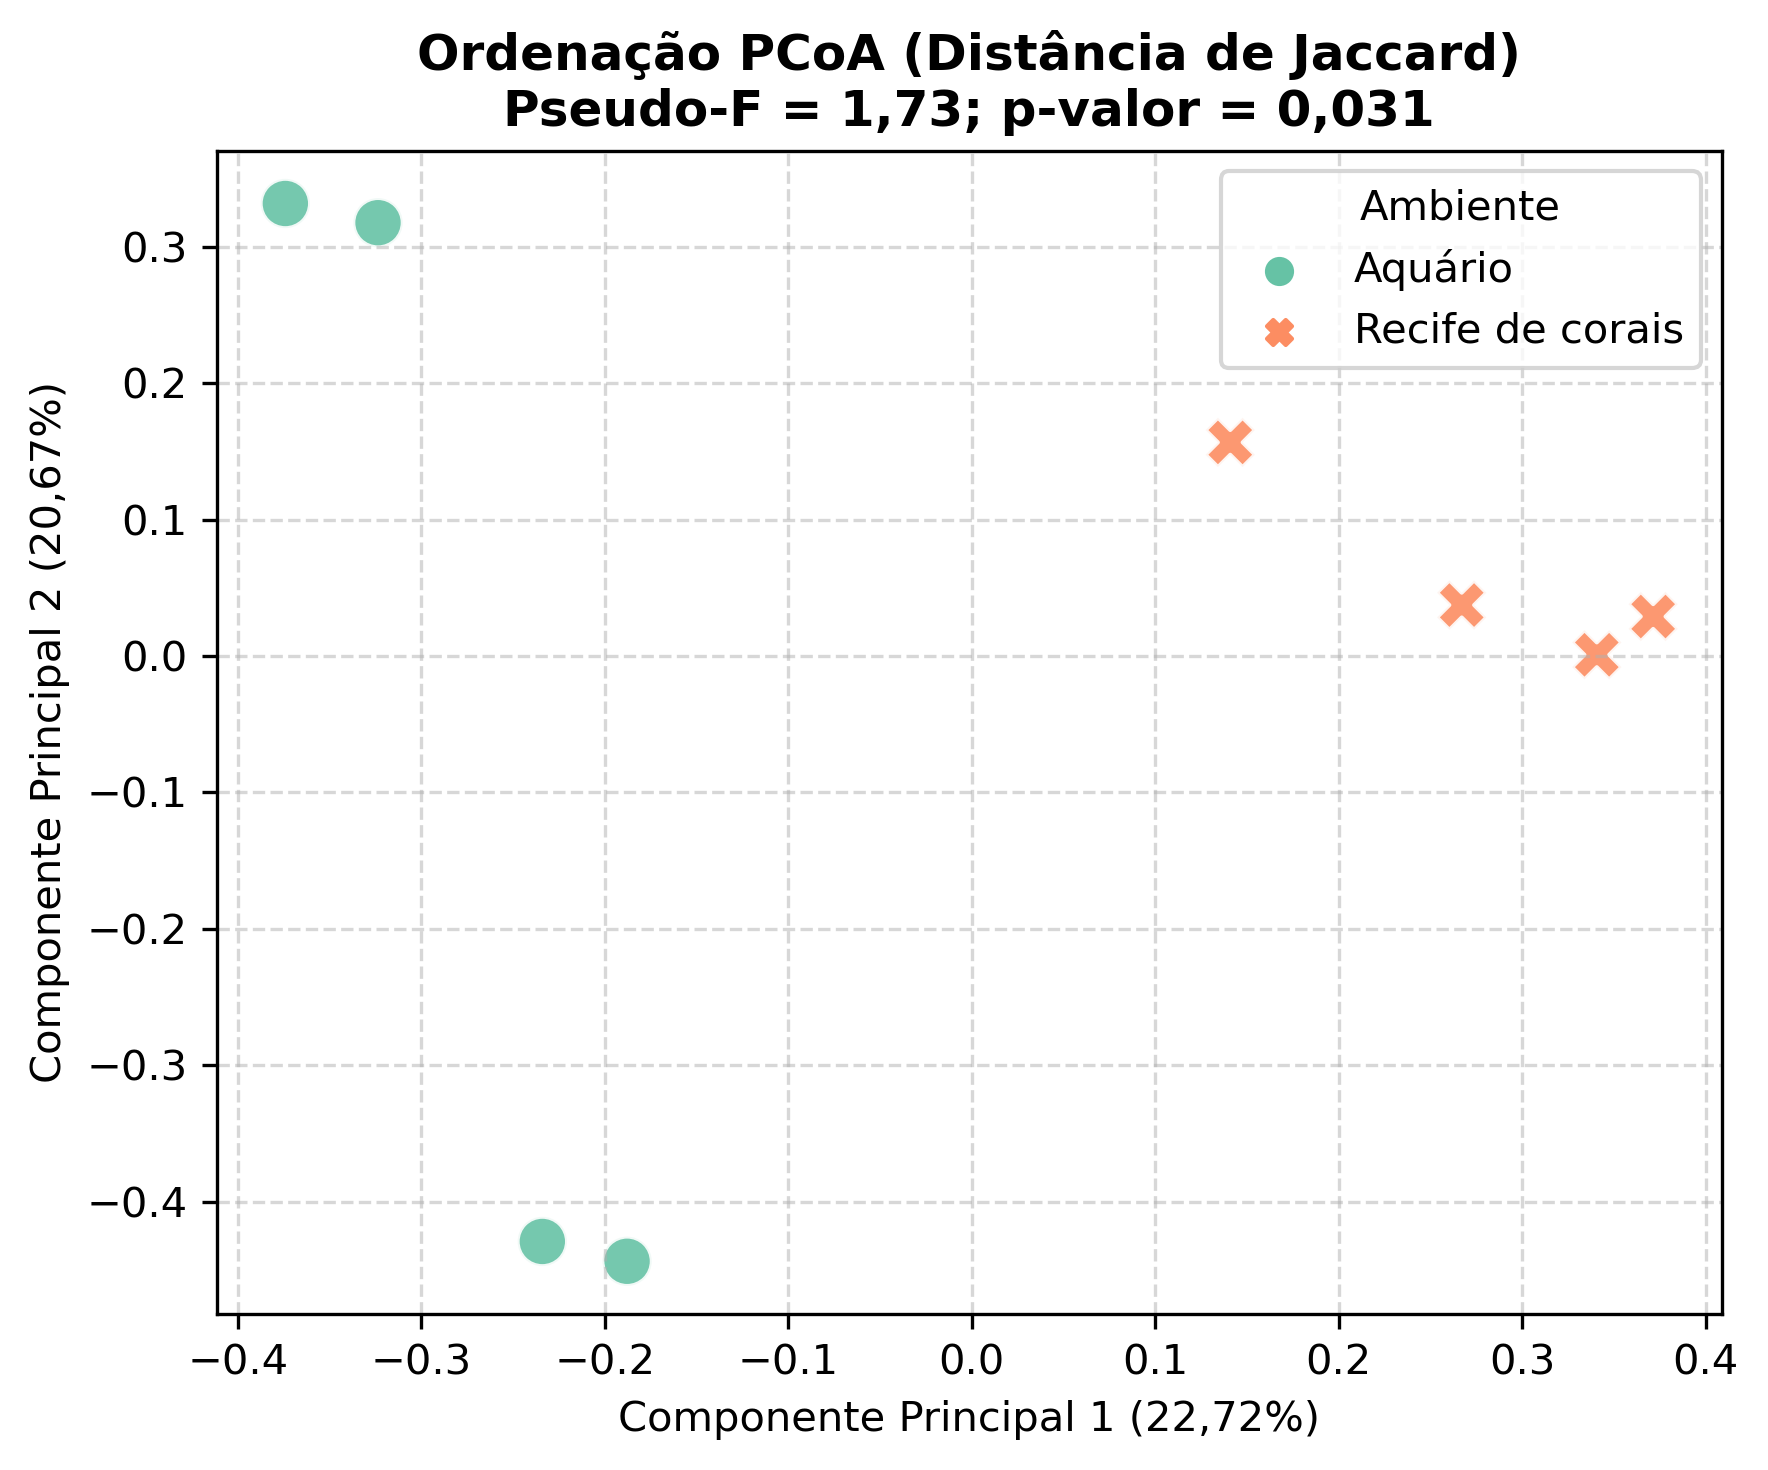

In [301]:
# Plotar o gráfico de dispersão (pcoa)
plt.figure(figsize=(6, 5),dpi=300)

sns.scatterplot(
    data=df_beta, 
    x='PC1', 
    y='PC2', 
    hue='escala_local', 
    style='escala_local', 
    s=140, 
    palette='Set2',
    alpha=0.9
)

# Ajustes estéticos
plt.title('Ordenação PCoA (Distância de Jaccard)\nPseudo-F = 1,73; p-valor = 0,031', fontsize=12, fontweight='bold')
plt.xlabel('Componente Principal 1 (22,72%)', fontsize=10)
plt.ylabel('Componente Principal 2 (20,67%)', fontsize=10)
plt.legend(title='Ambiente', loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Salvar e mostrar a figura

plt.savefig('./figures/pcoa_jaccard.png', dpi=300)
plt.show()

## Taxonomia

In [302]:
# Carregar dados de taxonomia
tax_df = pd.read_csv('../4_output/2_exported_tables/3_taxonomy/taxonomy.tsv', sep='\t')
tax_df

,Feature ID,Taxon,Confidence
0,c91cdbde5a6b9a9399fd9b79fc8bb432,d__Eukaryota;p__Chordata;c__Actinopteri;o__Bel...,1.000000
1,b558a1c21ec4a57aeb33616418aa1f45,d__Eukaryota;p__Chordata;c__Actinopteri;o__Eut...,0.998991
2,3af1253c6f1be019b97f0ba2c740b0b2,d__Eukaryota;p__Chordata;c__Actinopteri;o__Sco...,0.997475
3,d02810de606dd39d77109f1fa5fbefad,d__Eukaryota;p__Chordata;c__Actinopteri;o__Ble...,1.000000
4,75b43daed3ea71ab78dba3d349e1a4a1,d__Eukaryota;p__Chordata;c__Actinopteri;o__Ble...,0.996495
...,...,...,...
345,acdbd24bbeefd18419edd24cdb43dbbf,d__Eukaryota;p__Chordata;c__Actinopteri,0.964228
346,a108230461feab278b3afe7fc973a431,d__Eukaryota;p__Chordata;c__Actinopteri;o__Bel...,1.000000
347,20c3947ac3c327659a8cb606e4073bef,d__Eukaryota;p__Chordata;c__Actinopteri;o__Arg...,0.999932
348,17e3caa86cb6f61dec0ec4b612a942ed,d__Eukaryota;p__Chordata;c__Actinopteri;o__Sto...,0.999976


In [303]:
# Desagregar dados em nível de família
def extrair_familia(tax_string):
    if 'f__' in tax_string:
        # Pega o que está depois de 'f__' e antes do próximo ponto e vírgula
        familia = tax_string.split('f__')[1].split(';')[0]
        return familia if familia.strip() != '' else 'Não Identificado';
    return 'Outros'

In [304]:
# Checar famílias encontradas
tax_df['Familia'] = tax_df['Taxon'].apply(extrair_familia)
print('Famílias identificadas:')
print(tax_df['Familia'].unique()[:10]) # Mostra as 10 primeiras para checar

Famílias identificadas:
['Belonidae' 'Monodactylidae' 'Gempylidae' 'Blenniidae' 'Mugilidae'
 'Outros' 'Siganidae' 'Lethrinidae' 'Pomacentridae' 'Mullidae']


In [305]:
# Carregar dados de taxonomia
biom_df = pd.read_csv('../4_output/2_exported_tables/3_taxonomy/feature_table.tsv', sep='\t', skiprows=1)
biom_df.rename(columns={biom_df.columns[0]: 'Feature ID'}, inplace=True)
biom_df

,Feature ID,DRR030421,DRR030422,DRR030423,DRR030424,DRR030425,DRR030426,DRR030427,DRR030428
0,c91cdbde5a6b9a9399fd9b79fc8bb432,0.0,5.0,0.0,9.0,63700.0,196361.0,0.0,0.0
1,b558a1c21ec4a57aeb33616418aa1f45,0.0,0.0,96067.0,27515.0,8.0,0.0,0.0,0.0
2,3af1253c6f1be019b97f0ba2c740b0b2,81662.0,34847.0,0.0,0.0,15.0,3.0,0.0,949.0
3,d02810de606dd39d77109f1fa5fbefad,0.0,0.0,0.0,0.0,17539.0,60712.0,0.0,0.0
4,75b43daed3ea71ab78dba3d349e1a4a1,0.0,0.0,0.0,0.0,18995.0,54187.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
345,acdbd24bbeefd18419edd24cdb43dbbf,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
346,a108230461feab278b3afe7fc973a431,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
347,20c3947ac3c327659a8cb606e4073bef,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
348,17e3caa86cb6f61dec0ec4b612a942ed,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0


In [306]:
# Mesclar dataframes
df_tax_abund = pd.merge(biom_df, tax_df[['Feature ID', 'Familia']], on='Feature ID')
df_tax_abund = df_tax_abund.groupby('Familia').sum(numeric_only=True).T
df_tax_abund.index.name = 'sample-id'
df_tax_abund = df_tax_abund.reset_index()
df_tax_abund

Familia,sample-id,Acanthuridae,Anguillidae,Apogonidae,Atherinidae,Balistidae,Bathylagidae,Belonidae,Blenniidae,Bothidae,...,Synaphobranchidae,Syngnathidae,Synodontidae,Tetragonuridae,Tetraodontidae,Toxotidae,Trachichthyidae,Triakidae,Tripterygiidae,Xenocyprididae
0,DRR030421,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,118.0,0.0,0.0,0.0,0.0,0.0,1685.0,40.0,0.0,0.0
1,DRR030422,173.0,0.0,0.0,0.0,0.0,0.0,264.0,251.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,954.0,0.0,0.0,0.0
2,DRR030423,6.0,0.0,20407.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,176.0,3.0,12111.0,0.0,0.0,0.0,0.0
3,DRR030424,0.0,0.0,2623.0,0.0,0.0,0.0,9.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4783.0,0.0,0.0,0.0,0.0
4,DRR030425,6473.0,0.0,8238.0,3405.0,897.0,0.0,66629.0,53993.0,168.0,...,0.0,1115.0,0.0,5.0,561.0,0.0,0.0,0.0,2704.0,3.0
5,DRR030426,7759.0,0.0,23898.0,9104.0,4287.0,0.0,212552.0,158335.0,79.0,...,0.0,0.0,114.0,6.0,0.0,0.0,0.0,0.0,1596.0,0.0
6,DRR030427,9687.0,3.0,0.0,1816.0,1646.0,2.0,6592.0,14392.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,577.0,0.0
7,DRR030428,7721.0,0.0,0.0,0.0,1705.0,0.0,2183.0,5273.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2366.0,0.0


In [307]:
# Mesclar com metadados
df_tax_abund = pd.merge(metadata[['sample-id', 'escala_local']], df_tax_abund, on='sample-id')

# Corrigir nomes dos ambientes
df_tax_abund['escala_local'] = df_tax_abund['escala_local'].replace({
    'Aquarium': 'Aquário',
    'Coral_reefs': 'Recife de corais'
})

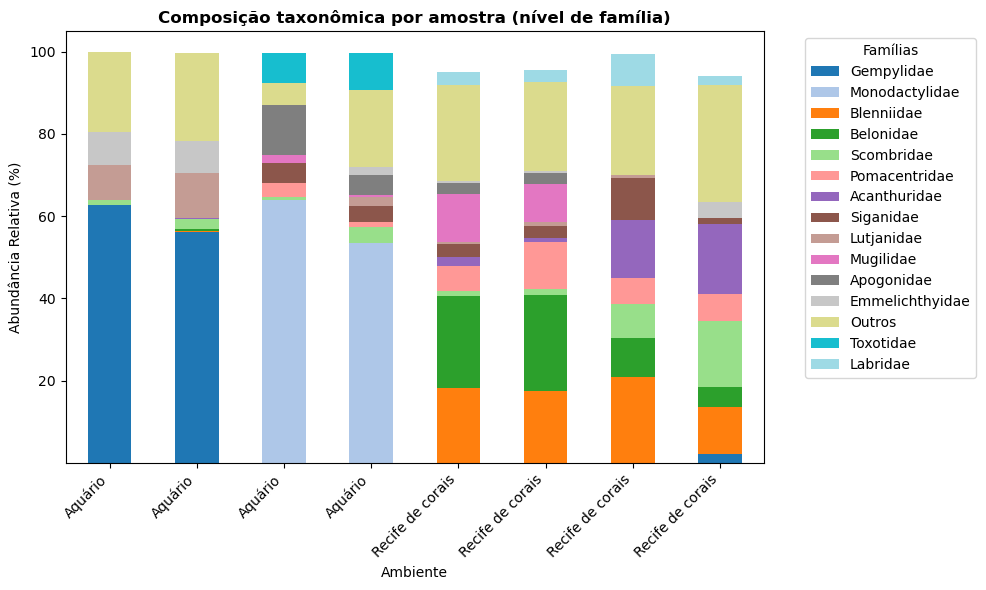

In [308]:
df_numeric = df_tax_abund.set_index('escala_local')

total_por_amostra = df_numeric.sum(axis=1, numeric_only=True)

df_prop = df_numeric.select_dtypes(include='number').div(total_por_amostra, axis=0) * 100

top_familias = df_prop.sum().nlargest(15).index
df_plot = df_prop[top_familias].copy()

#df_plot['Outros'] = 100 - df_plot.sum(axis=1)
df_plot['Outros'] = 100 - df_prop[top_familias].sum(axis=1)

ax = df_plot.plot(kind='bar', stacked=True, figsize=(10, 6), cmap='tab20')

plt.title('Composição taxonômica por amostra (nível de família)', fontsize=12, fontweight='bold')
plt.ylabel('Abundância Relativa (%)', fontsize=10)
plt.xlabel('Ambiente', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Famílias')
plt.tight_layout()

plt.savefig('./figures/barplot_taxonomia_n8.png', dpi=300)
plt.show()

In [309]:
# Agrupar por ambiente (Aquário vs Coral) e calcular a abundância média/proporcional
df_ambiente = df_tax_abund.groupby('escala_local').sum(numeric_only=True)
df_prop = df_ambiente.div(df_ambiente.sum(axis=1), axis=0) * 100

# Selecionar as top 15 famílias mais abundantes e jogar o resto em "Outros"
top_familias = df_prop.sum().nlargest(15).index
df_plot = df_prop[top_familias].copy()
df_plot['Outros'] = 100 - df_plot.sum(axis=1)

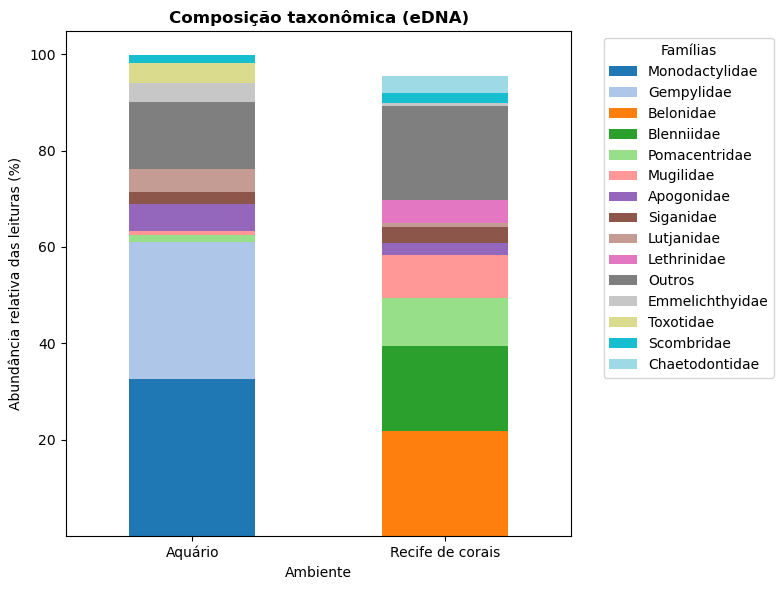

In [310]:
# Gráfico de barras
ax = df_plot.plot(kind='bar', stacked=True, figsize=(8, 6), cmap='tab20')

plt.title('Composição taxonômica (eDNA)', fontsize=12, fontweight='bold')
plt.ylabel('Abundância relativa das leituras (%)', fontsize=10)
plt.xlabel('Ambiente', fontsize=10)
plt.xticks(rotation=0)
plt.legend(title='Famílias', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Salvar e mostrar figura
plt.savefig('./figures/barplot_taxonomia.png', dpi=300)
plt.show()